<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Astronomia-de-posicion/Parcial3__AstroPos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Calculo &nbsp;de &nbsp;Fenomenos &nbsp;Astronomicos &nbsp;y &nbsp;Correccion &nbsp;de &nbsp;Coordenadas**
<br>

### &nbsp; **Astronomía de Posición:** &nbsp;&nbsp;Parcial $3$ - Parte practica

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*





<br>

___


In [ ]:
# Librerias
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import files
from astropy.time import Time
from datetime import datetime
%matplotlib inline

In [ ]:
# algunos parametros
rad    = np.pi/180        # grados a radianes
h_2_g  = 15               # horas a grados

J2000  = 2451545.0        # JD 2000
T_prec = 25776            # periodo de precesion [años]
dλ     = 360/T_prec       # vel. precesion [°/año]
e      = 23.44*rad        # oblicuidad [rads]
f = (24+3/60+56/(3600))/24 # factor escala tiempo solar-sideral

# **PUNTO 1) Fenomenos observacionales de las estrellas.**

###**(A) Identificacion de datos**

<p align="justify"> </p>

In [ ]:
# subir datos (nombre: stars.csv)
fil = files.upload()

Saving stars.csv to stars.csv


<p align="justify"> Tabla de datos de estrellas con 7 columnas con 1598 filas, con el sigiente contenido en orden: la primer columa pertenece al nombre de $identificacion$ de estrellas, segunda columna $Ascencion$ $recta$ en [horas minutos segundos], $Declinacion$ [grados minutos segundos], $movimiento$ $propio$: en ascencion recta $\mu_{\alpha}cos(\delta )$ [mas/yr], y en declinacion $\mu_{\delta}$ [mas/yr], $paralaje$ [mas], y $velocidad$ $radial$ [km/s]
</p><br>

###**(B) Lectura de datos y formato**

In [ ]:
# Leer datos con pandas
datos = pd.read_csv('stars.csv', sep=',') # datos separados por ','

# columnas como arreglos # datos.keys() # nombres de columnas
ID     = np.array(datos['ID'])
RA     = np.array(datos['AR [hms]'])
DEC    = np.array(datos['DEC [dms]'])
mu_RA  = np.array(datos['mu-ra*cos(dec) [mas/yr]'])
mu_DEC = np.array(datos['mu-dec [mas/yr]'])
PLX    = np.array(datos['plx [mas]'])
RV     = np.array(datos['radvel [km/s]'])

datos

,ID,AR [hms],DEC [dms],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s]
0,* tau Cyg,21 14 47.493,+38 02 43.144,196.990,410.280,49.1600,-20.900
1,* sig Cyg,21 17 24.952,+39 23 40.853,-0.130,-3.580,1.1300,-5.300
2,* 6 Lac,22 30 29.26,+43 07 24.156,-1.980,-5.360,1.9000,-8.700
3,* 11 Lac,22 40 30.859,+44 16 34.704,93.830,10.710,9.8000,-11.530
4,* psi And,23 46 2.047,+46 25 12.986,8.446,-7.143,1.6352,-23.163
...,...,...,...,...,...,...,...
1592,* 32 Eri A,03 54 17.502,-02 57 17.04,26.330,0.079,9.4562,26.300
1593,* del Ser A,15 34 48.145,+10 32 19.88,-73.952,5.748,10.8056,-20.820
1594,* phi Per,01 43 39.638,+50 41 19.433,24.590,-14.010,4.5400,0.800
1595,* alf Eri,01 37 42.845,-57 14 12.31,87.000,-38.240,23.3900,18.600


#### **Funciones de Conversión:**

Reutilizando las conversiones de la parte practica 2.

In [ ]:
def HMS_2_H(time_str):   # Transforma: (HH MM SS) a (HH)                         [para RA] ----------------------------------
    h, m, s = time_str.split(' ')
    return float(h) + float(m)/60 + float(s)/3600

def GMS_2_G(grade_str):  # Transforma: (° ' ") a (°)                             [para DEC] ---------------------------------
    g, m, s = grade_str.split(' ')
    if grade_str[0]=='-' : # condicion(-)
      return -(np.abs(float(g)) + float(m)/60 + float(s)/3600)
    else: return float(g) + float(m)/60 + float(s)/3600

def mas_2_g(mas_strg):   # Transforma: (mas) a (°)                               [para Mu_DEC] ------------------------------
    return float(mas_strg)*(10**-3)/3600

def mas_2_h(mas_strg):   # Transforma: (mas) a (h)                               [para Mu_RA] -------------------------------
    return float(mas_strg)*(10**-3)/(3600*h_2_g )

def str_2_f(strg):       # Transforma: (string) a (float)                        [para VR y PLX] ----------------------------
    return float(strg)

def YMD_2_JD(date_str):  # Transforma: (YYYY-MM-DD) a (JD)                       [para variable adimensional T] -------------
    y, m, d = date_str.split('-')
    m = datetime.strptime(m, '%b').month # pasa mes a numero
    JD = Time( str(y+'-'+str(m)+'-'+d) ).jd       # (yyyy mm dd) a (jd)
    return JD

def YMD_2_Y(str, fmtstr='%Y-%m-%d'): # Transforma: (YYYY-MM-DD) a (YYYY)         [para tiempo transcurrido t] ---------------
    t = datetime.strptime(str, fmtstr)
    t_first = datetime(t.year, 1, 1, 0, 0, 0)
    t_last = datetime(t.year, 12, 31, 0, 0, 0)
    return t.year + ((t-t_first).days/(t_last-t_first).days)

In [ ]:
# Aplicando conversiones a las columnas # todos tienen el mismo tamaño
ra_h   = np.zeros(len(RA)) # RA
dec_g  = np.zeros(len(RA)) # DEC
mu_ra  = np.zeros(len(RA)) # mov. propio RA
mu_dec = np.zeros(len(RA)) # mov. propio DEC
plx    = np.zeros(len(RA)) # paralaje
rv     = np.zeros(len(RA)) # vel. radial

for i in range(len(RA)):
  ra_h[i]  = HMS_2_H(RA[i])       # RA [h]
  dec_g[i] = GMS_2_G(DEC[i])      # DEC [°]
  mu_ra[i] = mas_2_h(mu_RA[i])    # mu_a [h/año]
  mu_dec[i]= mas_2_g(mu_DEC[i])   # mu_δ [°/año]
  plx[i]   = str_2_f(PLX[i])      # plx [mas]
  rv[i]    = str_2_f(RV[i])       # vr [km/s]

###**(C) Funciones de correcion de coordenadas: Precesión, Nutación y Movimiento Propio.**

<p align="justify"> Se creó una funcion independiente para cada caso, las cuales reciben la Ascensión recta y Declinación a corregir (en radianes), y el tiempo de diferencia entre la fecha deseada a corregir y la epoca J2000 (en años). (En el caso de la nutacion se usa en su lugar la variable $T$ especificada mas adelante).
Con las ecuaciones vistas en clase y las del libro Portilla, las funciones calculan y retornan: los valores finales corregidos de Ascensión recta $[h]$, declinación $[°]$, el cambio en Ascensión recta $Δ\alpha$ $[h]$, y el cambio en declinación $Δδ$ $[°]$. </p>

<p align="justify"> Como se tratan de arreglos de nympy las funciones pueden recibir el arreglo completo de cada uno de los imputs, realizar el calculo, y arrojar otro arreglo con todas las coordenadas corregidas mas sus respectivos cambios angulares. (En las funciones la notacion es $\alpha= a$).</p>

In [ ]:
def Precesion(a,δ,t):   # [rad,rad,años]
    # diferenciales de velocidad angular
    dδ = np.sin(e)*np.cos(a)* dλ                        # [°/año]
    da = (np.tan(δ)*np.sin(a)*np.sin(e)+ np.cos(e))* dλ # [°/año]

    # diferenciales de angulo
    Δa = da*t / h_2_g  # [h]
    Δδ = dδ*t          # [°]

    # correcion final:
    a_corr = a/(h_2_g*rad) + Δa  # [h]
    δ_corr = δ/rad + Δδ          # [°]

    return a_corr, δ_corr, Δa, Δδ   # [h,°,h,°]

En **La Correcion por Nutacion** (Elementos de astronomia, Portilla) se usan los siguientes parametros en funcion de $T= (JD-J2000)/36525$

> $Ω:$ Longitud ecliptica media del nodo ascendente de la orbita lunar sobre la ecliptica media desde el equinoccio de la fecha.<br>
> $D:$ Longitud ecliptica media de la Luna menos la longitud ecliptica media del Sol.<br>
> $F:$ Longitud ecliptica media de la Luna menos la del nodo lunar.

Con las coordenadas ecuatoriales $\alpha$ y $δ$ referidas al equinoccio medio de
la fecha (corregidas solo por precesion).

In [ ]:
def Nutacion(a,δ,T): # [rad,rad,adim]
    # parametros angulares [°]
    Ω = 125.04 - 1934.13*T
    D = 297.85 + 445267.11*T
    F = 93.27 + 483202.0175*T

    # angulos a primer circulo [rad]
    Ω = (Ω - int(Ω /360)*360)*rad
    D = (D - int(D /360)*360)*rad
    F = (F - int(F /360)*360)*rad

    if Ω < 0: Ω = Ω + 2*np.pi # caso angulos negativos [rad]
    if D < 0: D = D + 2*np.pi
    if F < 0: F = F + 2*np.pi

    # contribucion por longitud y oblicuidad [°]
    Δψ =(-17.2*np.sin(Ω) + 0.2*np.sin(2*Ω) - 1.3*np.sin(2*Ω+2*F-2*D) - 0.2*np.sin(2*Ω+2*F))/3600 # coeficientes en ["] pasan a [°]
    Δe =(9.2*np.cos(Ω) - 0.1*np.cos(Ω) + 0.6*np.cos(2*Ω+2*F-2*D) + 0.1*np.cos(2*Ω+2*F))/3600

    # oblicuidad
    e = (23.43928 - 0.0130028*T)*rad # [rads]
    e_v = e + Δe*rad                 # [rads]

    # diferenciales de RA y DEC
    Δa =( (np.cos(e) + np.sin(e)*np.sin(a)*np.tan(δ))*Δψ - np.cos(a)*np.tan(δ)*Δe  ) / h_2_g # [h]
    Δδ = np.sin(e)*np.cos(a)*Δψ  +  np.sin(a)*Δe # [°]

    # correciones finales
    a_f = a / (h_2_g*rad)  +  Δa   # [h]
    δ_f = δ / rad  +  Δδ           # [°]

    return a_f, δ_f, Δa, Δδ    # [h,°,h,°]

**El Movimiento Propio** se puede descomponer en las componentes de  Ascensión recta y declinacion, de la siguiente forma:

$$\mu^{2}=\mu_{\alpha}^{2}cos^{2}(\delta)+\mu_{\delta}^{2}$$

<p align="justify"> Como $\mu$ tiene unidades de velocidad angular, se puede obtener la posicion final de la estrella conociendo su posicion inicial, las componentes de velocidad $\mu$, y el tiempo en el que se ha estado desplazando. Esta posicion final serán las coordenadas corregidas, y ademas con esta y la posicion inicial se puede obtener el cambio angular de correcion del siguiente modo: </p>

> Componente en Declinación:
$$\mu_{\delta}=(\delta_{f}-\delta_{o})/t$$
$$\delta_{f} = \delta_{o} + \mu_{\delta}*t \quad\quad \wedge \quad\quad \Delta \delta = \delta_{f} - \delta_{o} $$


> Componente en Ascensión recta:
$$\mu_{\alpha}*cos(\delta)=(\alpha_{f}-\alpha_{o})/t$$
$$\alpha_{f} = \alpha_{o} + \mu_{\alpha}cos(\delta)*t \quad\quad \wedge \quad\quad \Delta \alpha = \alpha_{f} - \alpha_{o}$$


Bibliografia:
* Proper motion, Recuperado de: https://en.wikipedia.org/wiki/Proper_motion

In [ ]:
def Mov_propio(a, δ, mu_a, mu_δ, t):  # [h,°,h/año,°/año,años]
    # coordenadas finales
    a_f = a + mu_a*t # RA final [h]
    δ_f = δ + mu_δ*t # DEC final [°]

    # cambio en coordenadas
    Δa = a_f - a     # cambio en RA [h]
    Δδ = δ_f - δ     # cambio en DEC [°]

    return a_f, δ_f, Δa, Δδ  # [h,°,h,°]

<br>

###**(D) Cambio $\Delta \alpha$ y $\Delta \delta$ junto con coordenadas corregidas asociadas a cada caso**


In [ ]:
date = '2023-may-25'  # cualquier fecha entrante a realizar la correcion

# para nutacion
jd = YMD_2_JD(date)   # fecha [dias julianos]
T = (jd-J2000)/36525  # variable adimensional T

# para el resto
x = YMD_2_Y('2023-05-25','%Y-%m-%d') # fecha [años]
t = x-2000                           # años entre epoca(J2000) y fecha deseada

print('Fecha actual en dias julianos = ', jd)
print('Variable T =', T)
print('Años transcurridos desde J2000 hasta la fecha: t =', t)

Fecha actual en dias julianos =  2460089.5
Variable T = 0.23393566050650239
Años transcurridos desde J2000 hasta la fecha: t = 23.395604395604323


In [ ]:
# Correccion por Precesion
ra_prec, dec_prec, Δa_prec, Δδ_prec = Precesion(ra_h*(h_2_g*rad), dec_g*(rad), t) # in: [rad,rad,años] # out: [h,°,h,°]
# Correccion por Nutacion
ra_nut, dec_nut, Δa_nut, Δδ_nut     = Nutacion(ra_h*(h_2_g*rad), dec_g*(rad), T)  # in: [rad,rad,adim]  # out: [h,°,h,°]
# Correccion por Movimiento Propio
ra_mp, dec_mp, Δa_mp, Δδ_mp         = Mov_propio(ra_h, dec_g, mu_ra, mu_dec, t)   # in: [h,°,h/años,°/años,años] # out: [h,°,h,°]


# Ejemplo de visualizacion para primer estrella de la tabla
print('Ejemplo de visualizacion para la primera estrella de la tabla:')
print(' a=',ra_h[0], 'h')
print(' δ0=',dec_g[0], '°\n')

print('Primeros valores corregidos: precesion')
print(' a_prec[0]=',ra_prec[0],'h , Δa=', Δa_prec[0],'h' )
print(' δ_prec[0]=',dec_prec[0],'° , Δδ=', Δδ_prec[0],'°',)
print('Primeros valores corregidos: Nutacion')
print(' a_nut[0]=',ra_nut[0],'h  , Δa=', Δa_nut[0],'h' )
print(' δ_nut[0]=',dec_nut[0],'°  , Δδ=', Δδ_nut[0],'°',)
print('Primeros valores corregidos: Movimiento propio')
print(' a_mp[0]=',ra_mp[0],'h  , Δa=', Δa_mp[0],'h' )
print(' δ_mp[0]=',dec_mp[0],'°  , Δδ=', Δδ_mp[0],'°',)

Ejemplo de visualizacion para la primera estrella de la tabla:
 a= 21.246525833333333 h
 δ0= 38.045317777777775 °

Primeros valores corregidos: precesion
 a_prec[0]= 21.262036080635177 h , Δa= 0.01551024730184509 h
 δ_prec[0]= 38.142963240120146 ° , Δδ= 0.09764546234237374 °
Primeros valores corregidos: Nutacion
 a_nut[0]= 21.24631508503324 h  , Δa= -0.00021074830009626383 h
 δ_nut[0]= 38.04315431751424 °  , Δδ= -0.002163460263535235 °
Primeros valores corregidos: Movimiento propio
 a_mp[0]= 21.246611179631664 h  , Δa= 8.534629833079066e-05 h
 δ_mp[0]= 38.047984096825395 °  , Δδ= 0.002666319047619936 °


In [ ]:
print('Maximos cambios:')
print(' Δa_prec=', max(np.abs(Δa_prec)), 'h,   Δδ_prec=',max(np.abs(Δδ_prec)),'°')
print(' Δa_nut=', max(np.abs(Δa_nut)), 'h,  Δδ_nut=', max(np.abs(Δδ_nut)),'°')
print(' Δa_mp=', max(np.abs(Δa_mp)), 'h,  Δδ_mp=', max(np.abs(Δδ_mp)),'°')

print('\nCambios promedio:')
print(' Δa_prec=', np.mean(np.abs(Δa_prec)), 'h,  Δδ_prec=',np.mean(np.abs(Δδ_prec)),'°')
print(' Δa_nut=', np.mean(np.abs(Δa_nut)), 'h, Δδ_nut=', np.mean(np.abs(Δδ_nut)),'°')
print(' Δa_mp=', np.mean(np.abs(Δa_mp)), 'h,  Δδ_mp=', np.mean(np.abs(Δδ_mp)),'°')
# se tomaron val abs para no afectar el calculo de la media y maximos

Maximos cambios:
 Δa_prec= 0.4349096363846638 h,   Δδ_prec= 0.12997907725638153 °
 Δa_nut= 0.011970351179045602 h,  Δδ_nut= 0.002304780566972448 °
 Δa_mp= 0.0017185635468059957 h,  Δδ_mp= 0.02223758046703317 °

Cambios promedio:
 Δa_prec= 0.020355548860824146 h,  Δδ_prec= 0.07802036127786847 °
 Δa_nut= 0.00021345831675460288 h, Δδ_nut= 0.0015172321976018397 °
 Δa_mp= 3.7004184078498416e-05 h,  Δδ_mp= 0.0004541683463766758 °


In [ ]:
# Tabla de cambios de las coordenadas por cada metodo
cambios = {'Δa_prec':Δa_prec,'Δδ_prec':Δδ_prec,
           'Δa_nut':Δa_nut,'Δδ_nut':Δδ_nut,
           'Δa_mp':Δa_mp,'Δδ_mp':Δδ_mp}

tabla_cambios = pd.DataFrame(cambios)
tabla_cambios

,Δa_prec,Δδ_prec,Δa_nut,Δδ_nut,Δa_mp,Δδ_mp
0,0.015510,0.097645,-0.000211,-0.002163,8.534630e-05,2.666319e-03
1,0.015350,0.098621,-0.000214,-0.002154,-5.632275e-08,-2.326563e-05
2,0.016896,0.120191,-0.000260,-0.001789,-8.578388e-07,-3.483346e-05
3,0.017114,0.122240,-0.000269,-0.001724,4.065203e-05,6.960192e-05
4,0.019431,0.129738,-0.000306,-0.001222,3.659246e-06,-4.642078e-05
...,...,...,...,...,...,...
1592,0.019604,0.067773,-0.000162,0.001154,1.140752e-05,5.134035e-07
1593,0.018687,-0.076948,-0.000143,-0.000980,-3.203985e-05,3.735498e-05
1594,0.024611,0.116909,-0.000357,-0.000105,1.065367e-05,-9.104789e-05
1595,0.014417,0.118343,0.000069,-0.000165,3.769292e-05,-2.485133e-04


<p align="justify"> Como se puede observar de los cambios de las coordenadas, el fenomeno que causa cambios mas notables es el de $Precesión$, con una media de variacion del orden de magnitud de $10^{-2}$, es decir afecta en promedio la segunda cifra cignificativa despues del punto; las centesimas de los valores de las coordenadas, tanto Ascensión recta como en declinación. Seguido por los cambios de Nutación, que estan en promedio en el orden $10^{-4}$ para Ascensión recta y $10^{-3}$ para declinación. Siendo finalmente el menos notable el cambio por Movimiento Propio, estando su cambio medio en los ordenes $10^{-5}$ para Ascensión recta y $10^{-4}$ para declinación.</p><br>

###**(E) Correcion total de las coordenadas**

En el punto anterior se obtuvieron las coordenadas corregidas independientemente por cada metodo, sin embargo, juntando los 3 para realizar una correccion total, se creó una funcion que primero corrige por Precesion, luego Nutacion y finalmente por Movimiento propio.

In [ ]:
def Correccion_total(ra, dec, t, T, mu_ra, mu_dec): # [h,°,años,adim,h/año,°/año]

    ra_c1, dec_c1, Δra1, Δdec1  = Precesion(ra*(h_2_g*rad) , dec*(rad) , t)      # in: [rad,rad,años] # out: [h,°,h,°]
    ra_c2, dec_c2, Δra2, Δdec2  = Nutacion(ra_c1*(h_2_g*rad), dec_c1*(rad), T)   # in: [rad,rad,adim] # out: [h,°,h,°]
    ra_c3, dec_c3, Δra3, Δdec3  = Mov_propio(ra_c2, dec_c2, mu_ra, mu_dec, t)    # in: [h,°,h/año,°/año,años] # out: [h,°,h,°]

    return ra_c3 , dec_c3

Correccion_total(ra_h, dec_g, t, T, mu_ra, mu_dec)

(array([21.26191007, 21.30540007, 22.52476229, ...,  1.7519413 ,
         1.64309107, 23.75262373]),
 array([ 38.14346934,  39.49112861,  43.24175005, ...,  50.80545872,
        -57.11881435,  29.48962135]))

###**(F) Distancia de cada estrella al sol en parsecs**

Por paralaje anual se puede obter la distancia $d$ del sol a un objeto lejano, de la siguiente forma:

<p align="center">
<img src=https://i.postimg.cc/QMCMVZb1/paralax.jpg width="400">
<br>
<font size=2>Fig1. Diagrama paralaje en la orbita terrestre.</font></p>


$$tan(p)=\frac{b}{d} = \frac{1\mathrm{UA}}{d} \Rightarrow d=\frac{1\mathrm{UA}}{tan(p)}=\frac{1\mathrm{UA}}{p} $$


Siempre que $d>>1\mathrm{UA}$, se cumple que $tan(p)\approx p$, con $p[rads]$,
y puesto que el Pasec se define como la distancia por paralaje para $p=1$ arco segundo, y teniendo en cuenta que $1$ $mas$= $1*10^{-3}s$, entonces se obtiene que la distancia del sol a un objeto lejano en parsecs equivale a:

$$d[\mathrm{pc}] = \frac{1}{p["]}=\frac{1000}{p[mas]}$$

In [ ]:
def Distancia_pc(p): # [mas]
  return 1000/p # [pc]

print('distancia del sol a cada estrella en parsecs:')
distancia = Distancia_pc(plx) # [pc]
distancia

distancia del sol a cada estrella en parsecs:


array([ 20.34174125, 884.95575221, 526.31578947, ..., 220.26431718,
        42.75331338,  69.9726407 ])

###**(G) Movimiento propio total de cada estrella**

Para el movimiento propio total, se tiene:

$$\mu^{2}=\mu_{\alpha}^{2}cos^{2}(\delta)+\mu_{\delta}^{2}$$
$$\mu=[\quad \mu_{\alpha}^{2}cos^{2}(\delta)+\mu_{\delta}^{2}\quad]^{0.5}$$



In [ ]:
# la componente RA [h/año], se pasa a [°/año] para poder sumarla con la
# componente DEC, y para dimensionar el resultado se deja en [°] y no [mas]
mu_total = ((mu_ra*(h_2_g))**2 + mu_dec**2)**.5  # [°/año]

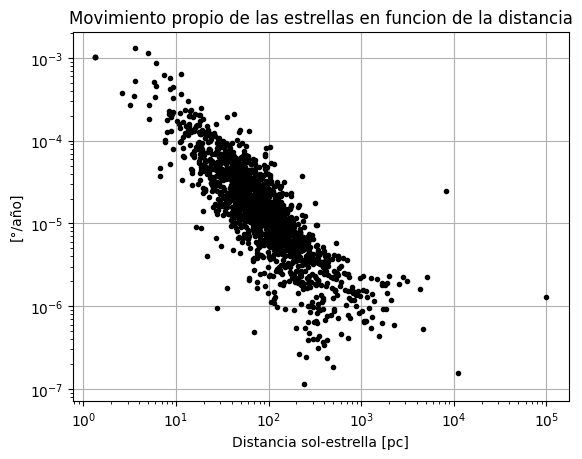

In [ ]:
plt.plot(distancia, mu_total,'k.')
plt.title('Movimiento propio de las estrellas en funcion de la distancia')
plt.xlabel('Distancia sol-estrella [pc]')
plt.ylabel('[°/año]')
plt.xscale('log')
plt.yscale('log')
plt.grid()

<p align="justify"> Se observa que a medida que las estrellas se encuentran mas lejos, estas tienen un movimiento propio total menor. Mientras que si se encunetran mas cerca a su observador, nosotros, su movimiento propio o velocidad será mayor.
En general se puede decir que se cumple de manera intuitiva, pues suponiendo una velocidad aparentemente constante para todos los objetos en cierta region del espacio, a los mas lejanos en el mismo tiempo barreran una distancia menor que los que se encuentran mas cerca, por lo que la velocidad aparente de los objetos lejanos es menor que la velocidad de los mas cercanos. </p><br>



###**(H) Velocidad tangencial de las estrellas**
Como se trata de la velocidad perpendicular a la linea de vision, se toma el movimiento propio y se multiplica por la distancia a la estrella. De modo que en este caso:

$$ v_{t}= w * r = μ * d $$

Si esta velocidad tangencia se toma constante, entonces para un segundo instante se tiene:

$$ v_{t} = μ * d = μ_{1} * d_{1} $$
$$  μ_{1}= \frac{v_{t}}{d_{1}}$$


Tenemos que encontrar el segundo radio, $d_{1}$, y con este finalmente el cambio en $μ_{1}$

<p align="center">
<img src=https://i.postimg.cc/G2tqvKP3/Whats-App-Image-2023-06-02-at-10-30-49-PM.jpg width="400">
<br>



In [ ]:
Δt = 400 # años
v_t = (mu_total *rad) * distancia # vel tangencial [pc/años]

# se puede obtener la velocidad total de las componentes radial y tangencial:
v = ( v_t**2  +  ( rv*(3.2408e-14)*(24*365.25) )**2  )**.5 # [pc/año]

# multiplicando esta velocidad total por el tiempo para ver la distancia recorrida d':
d = v * Δt #[pc]

# se forma un triangulo entre d´ y d0, y conociendo el angulo θ entre ambos
# podemos encontrar el desplazamiento total con teorema de coseno:

θ = np.arctan( v_t / (rv*(3.2408e-14)*(24*365.25)) )

d1 = (distancia**2 + d**2 - 2*d*distancia*np.cos(θ))**.5 # [pc]

# finalmente despejando el movimiento propio en el segundo instante
mu_1 = v_t / d1 # []
mu_1

print('El cambio del movimiento propio en 400 años es: [rad/año]')
print( mu_total*rad - mu_1, '\n')
# son valores muy pequeños

El cambio del movimiento propio en 400 años es: [rad/año]
[ 6.01780886e-13 -1.14007491e-17 -5.03351480e-17 ...  1.50014564e-16
 -1.49533414e-14 -4.76321937e-16] 



<ipython-input-59-f0d20f686e00>:13: RuntimeWarning: divide by zero encountered in true_divide
  θ = np.arctan( v_t / (rv*(3.2408e-14)*(24*365.25)) )


<br><br>
___

# **PUNTO 2) El sol y la duracion de los dias**



In [ ]:
ast = !pip install astroquery
from astroquery.jplhorizons import Horizons

###**(A) Datos observacionales del sol para cada dia del 2022 con referencia al barivcentro terrestre.** <br><br>


La clase ```Horizons``` de ```astroquery.jplhorizons``` tiene ciertos atributos interesantes, como

> ```.ephemerides()```: Tabla de datos que contiene trayectoria de objetos astronómicos, incluye datos como posición, velocidad, entre otros; asociados a un intervalo o tiempo dado. La posición suele darse en ascensión recta y declinación.
<br>
> ```.vectors()```: Tabla de datos con datos de posicion(x,y,z), velocidad(vx,vy,vz)... entre otros; Para un intervalo o tiempo dado.
<br>
> ```.elements()```: Tabla de datos que retorna los elementos orbitales relativos a un cuerpo particular del sistema solar; para un intervalo o tiempo dado.


**Bibliografia:**

* Informacion de Astroquery jplhorizons. Recuperado de: https://astroquery.readthedocs.io/en/latest/jplhorizons/jplhorizons.html

* Definicion de Efemerides. Recuperado de: https://en.wikipedia.org/wiki/Ephemeris

In [ ]:
# intervalo de tiempo para los datos
start = datetime(2022,1,1)
end   = datetime(2022,12,31)
step_size ='1d'

interval = {'start':start.strftime("%Y-%m-%d %H:%M"),
            'stop':end.strftime("%Y-%m-%d %H:%M"),
            'step':step_size}

sol = Horizons(id='sun',location='500@3',epochs=interval) # objeto a estudar
sol_eph = sol.ephemerides() # efemerides: RA, DEC,...
sol_eph

targetname,datetime_str,datetime_jd,solar_presence,flags,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,AZ,EL,AZ_rate,EL_rate,sat_X,sat_Y,sat_PANG,siderealtime,airmass,magextinct,V,surfbright,illumination,illum_defect,sat_sep,sat_vis,ang_width,PDObsLon,PDObsLat,PDSunLon,PDSunLat,SubSol_ang,SubSol_dist,NPole_ang,NPole_dist,EclLon,EclLat,r,r_rate,delta,delta_rate,lighttime,vel_sun,vel_obs,elong,elongFlag,alpha,IB_elong,IB_illum,sat_alpha,sunTargetPA,velocityPA,OrbPlaneAng,constellation,TDB-UT,ObsEclLon,ObsEclLat,NPole_RA,NPole_DEC,GlxLon,GlxLat,solartime,earth_lighttime,RA_3sigma,DEC_3sigma,SMAA_3sigma,SMIA_3sigma,Theta_3sigma,Area_3sigma,RSS_3sigma,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
---,---,d,---,---,deg,deg,deg,deg,arcsec / h,arcsec / h,deg,deg,arcsec / min,arcsec / min,arcsec,arcsec,deg,---,---,mag,mag,mag / arcsec2,%,arcsec,arcsec,---,arcsec,deg,deg,deg,deg,deg,arcsec,deg,arcsec,deg,deg,AU,km / s,AU,km / s,min,km / s,km / s,deg,---,deg,deg,%,deg,deg,deg,deg,---,s,deg,deg,deg,deg,deg,deg,---,min,arcsec,arcsec,arcsec,arcsec,deg,arcsec2,arcsec,km,km / s,Hz,Hz,s,deg,---,deg,deg,deg
str8,str17,float64,str1,str1,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,str1,float64,float64,float64,int64,int64,str3,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,int64,int64,float64,float64,float64,float64,str3,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64
Sun (10),2022-Jan-01 00:00,2459580.5,,,281.13008,-23.04213,281.12381,-23.04257,152.424,11.73022,--,--,--,--,0.0,0.0,0.0,--,999,--,-26.779,-10.589,100.0,0.0,0.0,-,1951.828,142.540182,-2.999388,--,--,n.a,--,2.2055,-974.577,--,--,0.0,0.0,0.98332917915375,-0.0250746,8.17809941,0.0,30.2853537,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.20839,Sgr,69.183891,280.2263136,0.0026938,286.13,63.87,11.499458,-8.839855,--,0.000242,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,280.2321,0.0027
Sun (10),2022-Jan-02 00:00,2459581.5,,,282.2337,-22.96006,282.22743,-22.96054,152.3352,12.87746,--,--,--,--,0.0,0.0,0.0,--,999,--,-26.779,-10.589,100.0,0.0,0.0,-,1951.852,129.369691,-3.116159,--,--,n.a,--,1.7202,-974.483,--,--,0.0,0.0,0.98331724223024,-0.0162608,8.17800013,0.0,30.2857174,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.1836,Sgr,69.18392,281.2454918,0.002681,286.13,63.87,12.019676,-9.720276,--,0.000242,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,281.2513,0.0027
Sun (10),2022-Jan-03 00:00,2459582.5,,,283.33593,-22.87036,283.32967,-22.87089,152.2366,14.01841,--,--,--,--,0.0,0.0,0.0,--,999,--,-26.779,-10.589,100.0,0.0,0.0,-,1951.866,116.199445,-3.231959,--,--,n.a,--,1.2349,-974.381,--,--,0.0,0.0,0.98331039730338,-0.0074419,8.1779432,0.0,30.2859274,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.15876,Sgr,69.18395,282.2646897,0.0026673,286.13,63.87,12.542648,-10.599924,--,0.000243,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,282.2705,0.0027
Sun (10),2022-Jan-04 00:00,2459583.5,,,284.43665,-22.77307,284.4304,-22.77365,152.1284,15.1525,--,--,--,--,0.0,0.0,0.0,--,999,--,-26.779,-10.589,100.0,0.0,0.0,-,1951.869,103.029438,-3.346748,--,--,n.a,--,0.7497,-974.27,--,--,0.0,0.0,0.98330864655139,0.0013794,8.17792864,0.0,30.2859835,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.13389,Sgr,69.183979,283.2838966,0.0026527,286.13,63.87,13.068638,-11.478712,--,0.000245,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,283.2897,0.0027
Sun (10),2022-Jan-05 00:00,2459584.5,,,285.53575,-22.66825,285.52951,-22.66887,152.011,16.27917,--,--,--,--,0.0,0.0,0.0,--,999,--,-26.779,-10.589,100.0,0.0,0.0,-,1951.863,89.859667,-3.460491,--,--,n.a,--,0.2649,-974.152,--,--,0.0,0.0,0.98331199052975,0.0102002,8.17795645,0.0,30.2858857,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.109,Sgr,69.184009,284.3031019,0.0026372,286.13,63.87,13.597912,-12.3

In [ ]:
ra_sol   = np.array(sol_eph['RA_app'])/h_2_g # [h]
dec_sol  = np.array(sol_eph['DEC_app'])     # [°]
date_sol = np.array(sol_eph['datetime_str']) # [yyyy-mm-dd hh:mm]
JD_sol   = np.array(sol_eph['datetime_jd'])  # [dias julianos]

###**(B) Dada la ubicacion de un observador, calculo de:** <br>
* ###  **Angulo horario $H_{s}$ y acimut del salida del sol $A_{s}$.**


In [ ]:
def H_A_salida(Φ,δ):    # [rad,rad]
    # HORARIO SALIDA
    if np.abs(Φ) < np.pi/2 - e: # existe hora de puesta y salida # me debe faltar una condicion
      H_P = np.arccos(-np.tan(δ)*np.tan(Φ)) / (h_2_g*rad) # [h]
      H_S = 24 - H_P                                      # [h]

    # ACIMUT SALIDA
    if Φ != np.pi/2: # en polos no definido
      A_S = (np.arccos( np.sin(δ)/np.cos(Φ)) ) / rad

    if np.abs(Φ) > np.pi/2 - e:
      H_P = np.array([None for x in range(len(δ))])
      H_S = np.array([None for x in range(len(δ))])

    return H_S, A_S

def altura_max(Φ,δ):  # [rad,rad]
    hmax = np.zeros(len(δ))
    hmax_app = np.zeros(len(δ))

    for i in range(len(δ)):
      if δ[i] > Φ:
        hmax[i] = 90 - δ[i]/rad + Φ/rad   # culmina N [°]
        hmax_app[i] = hmax[i] + 34/3600   # angulo de refraccion atm [°]
      if δ[i] < Φ:
        hmax[i] = 90 + δ[i]/rad - Φ/rad   # culmina S [°]
        hmax_app[i] = hmax[i] + 34/3600   # angulo de refraccion atm [°]

    return hmax, hmax_app # [°,°]


def find_hora(H,a,λ,JD):  # [h,h,°,jd]  funcion encontrar hora para tiempo salida,puesta
    TSL = a + H             # TSL (H puesta o salida)
    TSG = TSL - λ/15        # tsg (puesta o salida)[h]

    T = (JD - J2000)/36525
    TSG0 = (24110.54841 + 8640184.812866*T + 0.093104*T**2 + 0.0000062*T**3)/3600 # [h]

    UT = (TSG - TSG0)/f # [h]
    TL = UT +  int(λ/15) # UT + HH [h]

    return TL

def tiempo_s_p_c(H_P, H_S, a, λ, JD):
    if H_P[0]==None and H_S[0]==None:
      return  np.array([None for x in range(len(H_P))]),  np.array([None for x in range(len(H_P))]),  np.array([None for x in range(len(H_P))])
    TL_C = find_hora(0, a, λ, JD)
    TL_P = find_hora(H_P, a, λ, JD)
    TL_S = find_hora(H_S, a, λ, JD)

    return TL_C, TL_P, TL_S

def duracion_dia(TL_P,TL_S):
    Δdia = np.abs(TL_P - TL_S) # [h]
    return Δdia

def primer_circulo(x): # acta individual en tiempo_s_p_c
    x = x - int(x /24)*24
    if x < 0: x = x + 24
    return x

###**(C) Calculo para ciudades particulares:**<br>



In [ ]:
list_cities = ['Bodø','Jacksonville ','Alaspungo','Townsville','Durban']
λ_list = np.array([14.40501, -81.65565, -78.6, 146.818,31.0292])
Φ_list = np.array([67.28, 30.33218, 0, -19.2564,-29.8579])*rad

c0  = ['Bodø' for x in range(len(dec_sol))]
c1  = ['Jacksonville' for x in range(len(dec_sol))]
c2  = ['Alaspungo' for x in range(len(dec_sol))]
c3  = ['Townsville' for x in range(len(dec_sol))]
c4  = ['Durban' for x in range(len(dec_sol))]

###**(E) Dias mas cortos** <br>

In [ ]:
# florida jacksonville
H_s1, A_s1 = H_A_salida(Φ_list[1], dec_sol*rad)
hmax1, hmax_app1 = altura_max(Φ_list[1], dec_sol*rad)
TL_C1, TL_P1, TL_S1 = tiempo_s_p_c(24-H_s1, H_s1, ra_sol, λ_list[1], JD_sol)

for i in range(len(TL_C1)): # todos tiempos a primer circulo
  TL_C1[i]=primer_circulo(TL_C1[i])
  TL_P1[i]=primer_circulo(TL_P1[i])
  TL_S1[i]=primer_circulo(TL_S1[i])

Δdia1 = duracion_dia(TL_P1,TL_S1)

tabla1 = {'Fechas':date_sol,'ciudades':c1,'h_max_sol':hmax1,'Hora salida':TL_S1,
    'Hora puesta':TL_P1,'Duracion del dia':Δdia1}
pd.DataFrame(tabla1)

,Fechas,ciudades,h_max_sol,Hora salida,Hora puesta,Duracion del dia
0,2022-Jan-01 00:00,Jacksonville,36.62525,8.776399,18.892852,10.116453
1,2022-Jan-02 00:00,Jacksonville,36.70728,8.780354,18.904583,10.124229
2,2022-Jan-03 00:00,Jacksonville,36.79693,8.783863,18.916578,10.132714
3,2022-Jan-04 00:00,Jacksonville,36.89417,8.786921,18.928823,10.141902
4,2022-Jan-05 00:00,Jacksonville,36.99895,8.789523,18.941308,10.151785
...,...,...,...,...,...,...
360,2022-Dec-27 00:00,Jacksonville,36.32106,8.812855,18.900373,10.087517
361,2022-Dec-28 00:00,Jacksonville,36.36242,8.819061,18.910522,10.091461
362,2022-Dec-29 00:00,Jacksonville,36.41157,8.824852,18.920996,10.096144
363,2022-Dec-30 00:00,Jacksonville,36.46849,8.830221,18.931783,10.101561


In [ ]:
# Ecuador Alaspungo
H_s2, A_s2 = H_A_salida(Φ_list[2], dec_sol*rad)
hmax2, hmax_app2 = altura_max(Φ_list[2], dec_sol*rad)
TL_C2, TL_P2, TL_S2 = tiempo_s_p_c(24-H_s2, H_s2, ra_sol, λ_list[2], JD_sol)

for i in range(len(TL_C2)): # todos tiempos a primer circulo
  TL_C2[i]=primer_circulo(TL_C2[i])
  TL_P2[i]=primer_circulo(TL_P2[i])
  TL_S2[i]=primer_circulo(TL_S2[i])

Δdia2 = duracion_dia(TL_P2,TL_S2)

tabla2 = {'Fechas':date_sol,'ciudades':c2,'h_max_sol':hmax2,'Hora salida':TL_S2,
    'Hora puesta':TL_P2,'Duracion del dia':Δdia2}
pd.DataFrame(tabla2)

,Fechas,ciudades,h_max_sol,Hora salida,Hora puesta,Duracion del dia
0,2022-Jan-01 00:00,Alaspungo,66.95743,7.615126,19.647815,12.032688
1,2022-Jan-02 00:00,Alaspungo,67.03946,7.622970,19.655658,12.032688
2,2022-Jan-03 00:00,Alaspungo,67.12911,7.630721,19.663410,12.032688
3,2022-Jan-04 00:00,Alaspungo,67.22635,7.638372,19.671061,12.032688
4,2022-Jan-05 00:00,Alaspungo,67.33113,7.645916,19.678605,12.032688
...,...,...,...,...,...,...
360,2022-Dec-27 00:00,Alaspungo,66.65324,7.637115,19.669803,12.032688
361,2022-Dec-28 00:00,Alaspungo,66.69460,7.645292,19.677980,12.032688
362,2022-Dec-29 00:00,Alaspungo,66.74375,7.653424,19.686113,12.032688
363,2022-Dec-30 00:00,Alaspungo,66.80067,7.661503,19.694191,12.032688


In [ ]:
# Australia Townsville
H_s3, A_s3 = H_A_salida(Φ_list[3], dec_sol*rad)
hmax3, hmax_app3 = altura_max(Φ_list[3], dec_sol*rad)
TL_C3, TL_P3, TL_S3 = tiempo_s_p_c(24-H_s3, H_s3, ra_sol, λ_list[3], JD_sol)

for i in range(len(TL_C3)): # todos tiempos a primer circulo
  TL_C3[i]=primer_circulo(TL_C3[i])
  TL_P3[i]=primer_circulo(TL_P3[i])
  TL_S3[i]=primer_circulo(TL_S3[i])

Δdia3 = duracion_dia(TL_P3,TL_S3)

tabla3 = {'Fechas':date_sol,'ciudades':c3,'h_max_sol':hmax3,'Hora salida':TL_S3,
    'Hora puesta':TL_P3,'Duracion del dia':Δdia3}
pd.DataFrame(tabla3)

,Fechas,ciudades,h_max_sol,Hora salida,Hora puesta,Duracion del dia
0,2022-Jan-01 00:00,Townsville,86.21383,6.060055,19.229025,13.168970
1,2022-Jan-02 00:00,Townsville,86.29586,6.070172,19.234595,13.164423
2,2022-Jan-03 00:00,Townsville,86.38551,6.080405,19.239865,13.159460
3,2022-Jan-04 00:00,Townsville,86.48275,6.090744,19.244829,13.154084
4,2022-Jan-05 00:00,Townsville,86.58753,6.101179,19.249481,13.148301
...,...,...,...,...,...,...
360,2022-Dec-27 00:00,Townsville,85.90964,6.073586,19.259471,13.185885
361,2022-Dec-28 00:00,Townsville,85.95100,6.082916,19.266496,13.183580
362,2022-Dec-29 00:00,Townsville,86.00015,6.092417,19.273260,13.180844
363,2022-Dec-30 00:00,Townsville,86.05707,6.102078,19.279755,13.177677


In [ ]:
# Sudafrica Durban
H_s4, A_s4 = H_A_salida(Φ_list[4], dec_sol*rad)
hmax4, hmax_app4 = altura_max(Φ_list[4], dec_sol*rad)
TL_C4, TL_P4, TL_S4 = tiempo_s_p_c(24-H_s4, H_s4, ra_sol, λ_list[4], JD_sol)

for i in range(len(TL_C4)): # todos tiempos a primer circulo
  TL_C4[i]=primer_circulo(TL_C4[i])
  TL_P4[i]=primer_circulo(TL_P4[i])
  TL_S4[i]=primer_circulo(TL_S4[i])

Δdia4 = duracion_dia(TL_P4,TL_S4)

tabla4 = {'Fechas':date_sol,'ciudades':c4,'h_max_sol':hmax4,'Hora salida':TL_S4,
    'Hora puesta':TL_P4,'Duracion del dia':Δdia4}
pd.DataFrame(tabla4)

,Fechas,ciudades,h_max_sol,Hora salida,Hora puesta,Duracion del dia
0,2022-Jan-01 00:00,Durban,83.18467,6.386792,20.298739,13.911947
1,2022-Jan-02 00:00,Durban,83.10264,6.398446,20.302773,13.904327
2,2022-Jan-03 00:00,Durban,83.01299,6.410355,20.306367,13.896013
3,2022-Jan-04 00:00,Durban,82.91575,6.422508,20.309517,13.887009
4,2022-Jan-05 00:00,Durban,82.81097,6.434893,20.312218,13.877325
...,...,...,...,...,...,...
360,2022-Dec-27 00:00,Durban,83.48886,6.394604,20.334905,13.940301
361,2022-Dec-28 00:00,Durban,83.44750,6.404714,20.341150,13.936436
362,2022-Dec-29 00:00,Durban,83.39835,6.415140,20.346988,13.931848
363,2022-Dec-30 00:00,Durban,83.34143,6.425873,20.352412,13.926539


###**(E) Dias mas cortos y largos** <br>

In [ ]:
print('dias minimos:')
print(min(Δdia1))
print(min(Δdia2))
print(min(Δdia3))
print(min(Δdia4))
print(np.where(Δdia1==min(Δdia1)))
print(np.where(Δdia2==min(Δdia2)))
print(np.where(Δdia3==min(Δdia3)))
print(np.where(Δdia4==min(Δdia4)))

print(date_sol[np.where(Δdia1==min(Δdia1))])
print(date_sol[np.where(Δdia2==min(Δdia2))])
print(date_sol[np.where(Δdia3==min(Δdia3))])
print(date_sol[np.where(Δdia4==min(Δdia4))])

dias minimos:
10.078985212210114
12.032688489773136
10.87450686926013
10.116717424535636
(array([355]),)
(array([246, 301, 308]),)
(array([172]),)
(array([172]),)
['2022-Dec-22 00:00']
['2022-Sep-04 00:00' '2022-Oct-29 00:00' '2022-Nov-05 00:00']
['2022-Jun-22 00:00']
['2022-Jun-22 00:00']


En el caso del dia minimo, para la primer ciudad al norte que se pudo tabular, se da en la epoca del solsticio de invierno en el norte, para la segunda ciudad en el el ecuador el dia mas corto se dá en elequinicco se septiembre

In [ ]:
print('dias maximos:')
print(max(Δdia1))
print(max(Δdia2))
print(max(Δdia3))
print(max(Δdia4))
print(np.where(Δdia1==max(Δdia1)))
print(np.where(Δdia2==max(Δdia2)))
print(np.where(Δdia3==max(Δdia3)))
print(np.where(Δdia4==max(Δdia4)))

print(date_sol[np.where(Δdia1==max(Δdia1))])
# print(date_sol[np.where(Δdia2==max(Δdia2))])
print(date_sol[np.where(Δdia3==max(Δdia3))])
print(date_sol[np.where(Δdia4==max(Δdia4))])

dias maximos:
13.986390811877754
12.032688489773363
13.19087066853217
13.948660491207761
(array([172]),)
(array([ 79,  80,  81,  82,  84,  85,  86,  88,  91,  94,  95,  96,  99,
       100, 101, 102, 109, 110, 111, 112, 113, 115, 116, 118, 122, 123,
       124, 129, 132, 134, 135, 136, 137, 138, 139, 141, 149, 153, 155,
       158, 161, 163, 164, 166, 167, 170, 171, 177, 178, 182, 183, 184,
       186, 188, 189, 192, 193, 196, 198, 200, 203, 204, 214, 216, 217,
       220, 222, 223, 224, 231, 232, 236, 237, 238, 241, 248, 249, 251,
       254, 256, 257, 258, 262, 263, 264, 265, 269, 270, 272, 274, 281,
       282, 289, 291, 292, 294, 295, 297, 300, 304, 306, 309, 310, 311,
       313, 314, 316, 317, 319, 320, 322, 323, 324, 326, 328, 329, 331,
       334, 337, 338, 344, 345, 346, 347, 348, 349, 350, 355, 356, 357,
       358, 362, 363]),)
(array([355]),)
(array([355]),)
['2022-Jun-22 00:00']
['2022-Dec-22 00:00']
['2022-Dec-22 00:00']


Hay ciertas desviaciones, por ejemplo con el segundo conjunto de datos, que no toma un maximo unico sino muchisimos, sin embargo se puede observar que los dias mas largos encuentran cercanos a los solsticios de verano e invierno en el NORTE.